# Baseline Model — Oroua SafeSwim

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    recall_score, precision_score, fbeta_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 3
C_GRID = [0.001, 0.01, 0.1, 1, 10]
THRESHOLD_RANGE = np.arange(0.10, 0.91, 0.01)
TEMPORAL_CUTOFF = '2024-01-01'

RETAINED_FEATURES = [
    'rain_rangiwahia_maxhr_lag1',
    'rain_rangiwahia_total',
    'rain_mangaone_valley_total',
    'rain_mangaone_valley_maxhr_lag1',
    'rain_cheltenham_total',
    'rain_cheltenham_maxhr_lag1',
    'rain_halcombe_total',
    'rain_halcombe_maxhr_lag1',
    'wt_almadale_min_lag1',
    'flow_almadale_min_lag3',
    'flow_almadale_mean_lag2',
    'rain_heavy_count_7d',
]

# Zero imputation + missingness indicators (8 features)
RAINFALL_FEATURES = [
    'rain_rangiwahia_maxhr_lag1',
    'rain_rangiwahia_total',
    'rain_mangaone_valley_total',
    'rain_mangaone_valley_maxhr_lag1',
    'rain_cheltenham_total',
    'rain_cheltenham_maxhr_lag1',
    'rain_halcombe_total',
    'rain_halcombe_maxhr_lag1',
]

# Median imputation, no missingness indicators
OTHER_FEATURES = [
    'wt_almadale_min_lag1',
    'flow_almadale_min_lag3',
    'flow_almadale_mean_lag2',
    'rain_heavy_count_7d',
]

## Section 1 — Load Data

In [2]:
df = pd.read_csv('features_labelled.csv', index_col=0, parse_dates=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Label counts:\n{df['label'].value_counts().to_string()}")

X = df[RETAINED_FEATURES].copy()
y = df['label'].copy()

assert X.shape == (485, 12), f"Expected (485, 12), got {X.shape}"
assert y.sum() == 77
print(f"\nX shape: {X.shape}  |  Unsafe samples: {y.sum()}")

Shape: (485, 60)
Date range: 2005-07-13 to 2026-04-30
Label counts:
label
0.0    408
1.0     77

X shape: (485, 12)  |  Unsafe samples: 77.0


## Section 2 — Feature Selection and VIF Check

In [3]:
def compute_vif(X_df: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for each column in X_df (must be NaN-free)."""
    vif_vals = [
        variance_inflation_factor(X_df.values, i)
        for i in range(X_df.shape[1])
    ]
    return (
        pd.DataFrame({'feature': X_df.columns, 'VIF': vif_vals})
        .sort_values('VIF', ascending=False)
        .reset_index(drop=True)
    )

# Impute once for VIF on the full dataset (not inside CV — VIF is diagnostic only)
X_vif = X.copy()
X_vif[RAINFALL_FEATURES] = X_vif[RAINFALL_FEATURES].fillna(0)
X_vif[OTHER_FEATURES] = X_vif[OTHER_FEATURES].fillna(X_vif[OTHER_FEATURES].median())

vif_df = compute_vif(X_vif)
vif_df.to_csv('baseline_vif.csv', index=False)
print(vif_df.to_string())

# Drop features with VIF > 10
dropped_vif = vif_df.loc[vif_df['VIF'] > 10, 'feature'].tolist()
if dropped_vif:
    print(f"\nDropping for VIF > 10: {dropped_vif}")
else:
    print("\nNo features exceed VIF > 10. Retaining all 12.")

FINAL_FEATURES = [f for f in RETAINED_FEATURES if f not in dropped_vif]
FINAL_RAINFALL = [f for f in RAINFALL_FEATURES if f not in dropped_vif]
FINAL_OTHER = [f for f in OTHER_FEATURES if f not in dropped_vif]

X = X[FINAL_FEATURES].copy()
print(f"\nFinal feature count: {len(FINAL_FEATURES)}")
print(f"Final features: {FINAL_FEATURES}")

                            feature        VIF
0             rain_cheltenham_total  14.707593
1        rain_mangaone_valley_total  11.802473
2               rain_halcombe_total   9.592087
3        rain_cheltenham_maxhr_lag1   9.491620
4          rain_halcombe_maxhr_lag1   6.900742
5   rain_mangaone_valley_maxhr_lag1   6.667455
6             rain_rangiwahia_total   4.360938
7        rain_rangiwahia_maxhr_lag1   4.018475
8            flow_almadale_min_lag3   2.941327
9           flow_almadale_mean_lag2   2.471341
10             wt_almadale_min_lag1   1.989521
11              rain_heavy_count_7d   1.251918

Dropping for VIF > 10: ['rain_cheltenham_total', 'rain_mangaone_valley_total']

Final feature count: 10
Final features: ['rain_rangiwahia_maxhr_lag1', 'rain_rangiwahia_total', 'rain_mangaone_valley_maxhr_lag1', 'rain_cheltenham_maxhr_lag1', 'rain_halcombe_total', 'rain_halcombe_maxhr_lag1', 'wt_almadale_min_lag1', 'flow_almadale_min_lag3', 'flow_almadale_mean_lag2', 'rain_heavy_count_7

## Section 3 — Preprocessing Pipelines

In [4]:
def make_lr_pipeline(C: float = 1.0) -> Pipeline:
    """
    LR pipeline: zero-impute rainfall (+ missingness indicators),
    median-impute flow/temp/antecedent, StandardScale, L2 logistic regression.
    """
    preprocessor = ColumnTransformer([
        ('rain', SimpleImputer(strategy='constant', fill_value=0, add_indicator=True),
         FINAL_RAINFALL),
        ('other', SimpleImputer(strategy='median'), FINAL_OTHER),
    ], remainder='drop')
    return Pipeline([
        ('prep', preprocessor),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=1000,
            C=C,
            random_state=RANDOM_STATE,
        )),
    ])


def make_rf_pipeline() -> Pipeline:
    """
    RF pipeline: zero-impute rainfall (+ missingness indicators),
    median-impute flow/temp/antecedent. No scaling — trees are scale-invariant.
    """
    preprocessor = ColumnTransformer([
        ('rain', SimpleImputer(strategy='constant', fill_value=0, add_indicator=True),
         FINAL_RAINFALL),
        ('other', SimpleImputer(strategy='median'), FINAL_OTHER),
    ], remainder='drop')
    return Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            class_weight='balanced',
            max_features='sqrt',
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        )),
    ])


# Smoke test — fit each pipeline on a tiny slice to confirm no errors
_X_smoke = X.iloc[:20]
_y_smoke = pd.Series([0]*17 + [1]*3)
make_lr_pipeline(C=1.0).fit(_X_smoke, _y_smoke)
make_rf_pipeline().fit(_X_smoke, _y_smoke)
print("Pipeline smoke tests passed.")
print("LR steps:", [name for name, _ in make_lr_pipeline().steps])
print("RF steps:", [name for name, _ in make_rf_pipeline().steps])

C:\Users\mfg0631\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['rain_rangiwahia_maxhr_lag1' 'rain_mangaone_valley_maxhr_lag1'
 'rain_cheltenham_maxhr_lag1' 'rain_halcombe_maxhr_lag1']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
C:\Users\mfg0631\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['rain_rangiwahia_maxhr_lag1' 'rain_mangaone_valley_maxhr_lag1'
 'rain_cheltenham_maxhr_lag1' 'rain_halcombe_maxhr_lag1']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


Pipeline smoke tests passed.
LR steps: ['prep', 'scale', 'clf']
RF steps: ['prep', 'clf']


## Section 4 — Stratified 5-Fold Cross-Validation

In [5]:
def find_best_threshold(y_true: np.ndarray, y_proba: np.ndarray, beta: float = 2.0):
    """Return (threshold, f_beta) maximising F-beta on the provided fold."""
    best_t, best_score = 0.5, -1.0
    for t in THRESHOLD_RANGE:
        y_pred = (y_proba >= t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        if score > best_score:
            best_score, best_t = score, round(float(t), 2)
    return best_t, best_score


def compute_metrics(y_true: np.ndarray, y_proba: np.ndarray, threshold: float) -> dict:
    """Compute full evaluation metric set at a given decision threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'unsafe_recall':    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'unsafe_precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f2':               fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
        'roc_auc':          roc_auc_score(y_true, y_proba),
        'pr_auc':           average_precision_score(y_true, y_proba),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }

In [6]:
outer_cv = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
cv_y_true, cv_y_pred_lr, cv_y_pred_rf = [], [], []

for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # --- Logistic Regression: nested C grid search ---
    gs = GridSearchCV(
        make_lr_pipeline(),
        param_grid={'clf__C': C_GRID},
        cv=inner_cv,
        scoring='f1',
        refit=True,
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)
    best_C = gs.best_params_['clf__C']
    lr_proba = gs.predict_proba(X_val)[:, 1]
    lr_threshold, _ = find_best_threshold(y_val.values, lr_proba)
    lr_metrics = compute_metrics(y_val.values, lr_proba, lr_threshold)
    cv_rows.append({'fold': fold_idx, 'model': 'LR', 'threshold': lr_threshold,
                    'best_C': best_C, **lr_metrics})

    # --- Random Forest ---
    rf_pipe = make_rf_pipeline()
    rf_pipe.fit(X_train, y_train)
    rf_proba = rf_pipe.predict_proba(X_val)[:, 1]
    rf_threshold, _ = find_best_threshold(y_val.values, rf_proba)
    rf_metrics = compute_metrics(y_val.values, rf_proba, rf_threshold)
    cv_rows.append({'fold': fold_idx, 'model': 'RF', 'threshold': rf_threshold,
                    'best_C': None, **rf_metrics})

    # Collect predictions for aggregated CV confusion matrix (per-fold threshold)
    cv_y_true.extend(y_val.values)
    cv_y_pred_lr.extend((lr_proba >= lr_threshold).astype(int))
    cv_y_pred_rf.extend((rf_proba >= rf_threshold).astype(int))

    print(f"Fold {fold_idx} | "
          f"LR recall={lr_metrics['unsafe_recall']:.3f} t={lr_threshold:.2f} C={best_C} | "
          f"RF recall={rf_metrics['unsafe_recall']:.3f} t={rf_threshold:.2f}")

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('baseline_cv_results.csv', index=False)
print("\nSaved: baseline_cv_results.csv")

Fold 1 | LR recall=0.800 t=0.51 C=0.1 | RF recall=0.867 t=0.39


Fold 2 | LR recall=0.733 t=0.48 C=0.001 | RF recall=0.800 t=0.38


Fold 3 | LR recall=0.600 t=0.51 C=0.001 | RF recall=0.667 t=0.56


Fold 4 | LR recall=0.812 t=0.49 C=0.001 | RF recall=1.000 t=0.33


Fold 5 | LR recall=0.625 t=0.62 C=0.01 | RF recall=0.750 t=0.44

Saved: baseline_cv_results.csv


In [7]:
SUMMARY_COLS = ['unsafe_recall', 'unsafe_precision', 'f2',
                'roc_auc', 'pr_auc', 'balanced_accuracy', 'threshold']

cv_summary = cv_df.groupby('model')[SUMMARY_COLS].agg(['mean', 'std']).round(3)
print(cv_summary.to_string())

mean_threshold_lr = cv_df.loc[cv_df['model'] == 'LR', 'threshold'].mean()
mean_threshold_rf = cv_df.loc[cv_df['model'] == 'RF', 'threshold'].mean()
print(f"\nMean operational threshold — LR: {mean_threshold_lr:.3f}  RF: {mean_threshold_rf:.3f}")

      unsafe_recall        unsafe_precision            f2        roc_auc        pr_auc        balanced_accuracy        threshold       
               mean    std             mean    std   mean    std    mean    std   mean    std              mean    std      mean    std
model                                                                                                                                  
LR            0.714  0.098            0.606  0.117  0.682  0.072   0.828  0.047  0.656  0.047             0.809  0.042     0.522  0.056
RF            0.817  0.126            0.485  0.116  0.704  0.058   0.842  0.052  0.656  0.043             0.816  0.037     0.420  0.087

Mean operational threshold — LR: 0.522  RF: 0.420


## Section 5 — Temporal Hold-Out Evaluation (2024+)

In [8]:
cutoff = pd.Timestamp(TEMPORAL_CUTOFF)
train_mask = df.index < cutoff
test_mask  = df.index >= cutoff

X_ho_train, y_ho_train = X[train_mask], y[train_mask]
X_ho_test,  y_ho_test  = X[test_mask],  y[test_mask]

print(f"Hold-out train: {train_mask.sum()} rows, {y_ho_train.sum()} unsafe "
      f"(cutoff: {cutoff.date()})")
print(f"Hold-out test:  {test_mask.sum()} rows, {y_ho_test.sum()} unsafe")

holdout_rows = []

# LR — nested C search on hold-out training set
gs_ho = GridSearchCV(
    make_lr_pipeline(),
    param_grid={'clf__C': C_GRID},
    cv=StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    refit=True,
    n_jobs=-1,
)
gs_ho.fit(X_ho_train, y_ho_train)
lr_ho_proba = gs_ho.predict_proba(X_ho_test)[:, 1]
lr_ho_metrics = compute_metrics(y_ho_test.values, lr_ho_proba, mean_threshold_lr)
holdout_rows.append({'model': 'LR', 'threshold': mean_threshold_lr,
                     'best_C': gs_ho.best_params_['clf__C'], **lr_ho_metrics})

# RF — no inner tuning
rf_ho = make_rf_pipeline()
rf_ho.fit(X_ho_train, y_ho_train)
rf_ho_proba = rf_ho.predict_proba(X_ho_test)[:, 1]
rf_ho_metrics = compute_metrics(y_ho_test.values, rf_ho_proba, mean_threshold_rf)
holdout_rows.append({'model': 'RF', 'threshold': mean_threshold_rf,
                     'best_C': None, **rf_ho_metrics})

holdout_df = pd.DataFrame(holdout_rows)
holdout_df.to_csv('baseline_holdout_results.csv', index=False)
print("\nSaved: baseline_holdout_results.csv")
display_cols = ['model', 'threshold', 'unsafe_recall', 'unsafe_precision',
                'f2', 'roc_auc', 'pr_auc', 'balanced_accuracy']
print(holdout_df[display_cols].to_string(index=False))

Hold-out train: 393 rows, 66.0 unsafe (cutoff: 2024-01-01)
Hold-out test:  92 rows, 11.0 unsafe



Saved: baseline_holdout_results.csv
model  threshold  unsafe_recall  unsafe_precision       f2  roc_auc   pr_auc  balanced_accuracy
   LR      0.522       0.454545          0.555556 0.471698 0.826038 0.556364           0.702581
   RF      0.420       0.636364          0.500000 0.603448 0.808081 0.630099           0.774972


## Section 6 — Results Summary and Permutation Importance

In [9]:
METRIC_COLS = ['unsafe_recall', 'unsafe_precision', 'f2',
               'roc_auc', 'pr_auc', 'balanced_accuracy']

cv_mean = cv_df.groupby('model')[METRIC_COLS].mean().round(3)
cv_std  = cv_df.groupby('model')[METRIC_COLS].std().round(3)
cv_str  = cv_mean.astype(str).add(' ± ').add(cv_std.astype(str))
cv_str.index = [f"{m} (5-fold CV)" for m in cv_str.index]

ho_str = holdout_df.set_index('model')[METRIC_COLS].round(3).astype(str)
ho_str.index = [f"{m} (Hold-out 2024+)" for m in ho_str.index]

comparison = pd.concat([cv_str, ho_str]).sort_index()
print(comparison.to_string())

                     unsafe_recall unsafe_precision             f2        roc_auc         pr_auc balanced_accuracy
LR (5-fold CV)       0.714 ± 0.098    0.606 ± 0.117  0.682 ± 0.072  0.828 ± 0.047  0.656 ± 0.047     0.809 ± 0.042
LR (Hold-out 2024+)          0.455            0.556          0.472          0.826          0.556             0.703
RF (5-fold CV)       0.817 ± 0.126    0.485 ± 0.116  0.704 ± 0.058  0.842 ± 0.052  0.656 ± 0.043     0.816 ± 0.037
RF (Hold-out 2024+)          0.636              0.5          0.603          0.808           0.63             0.775


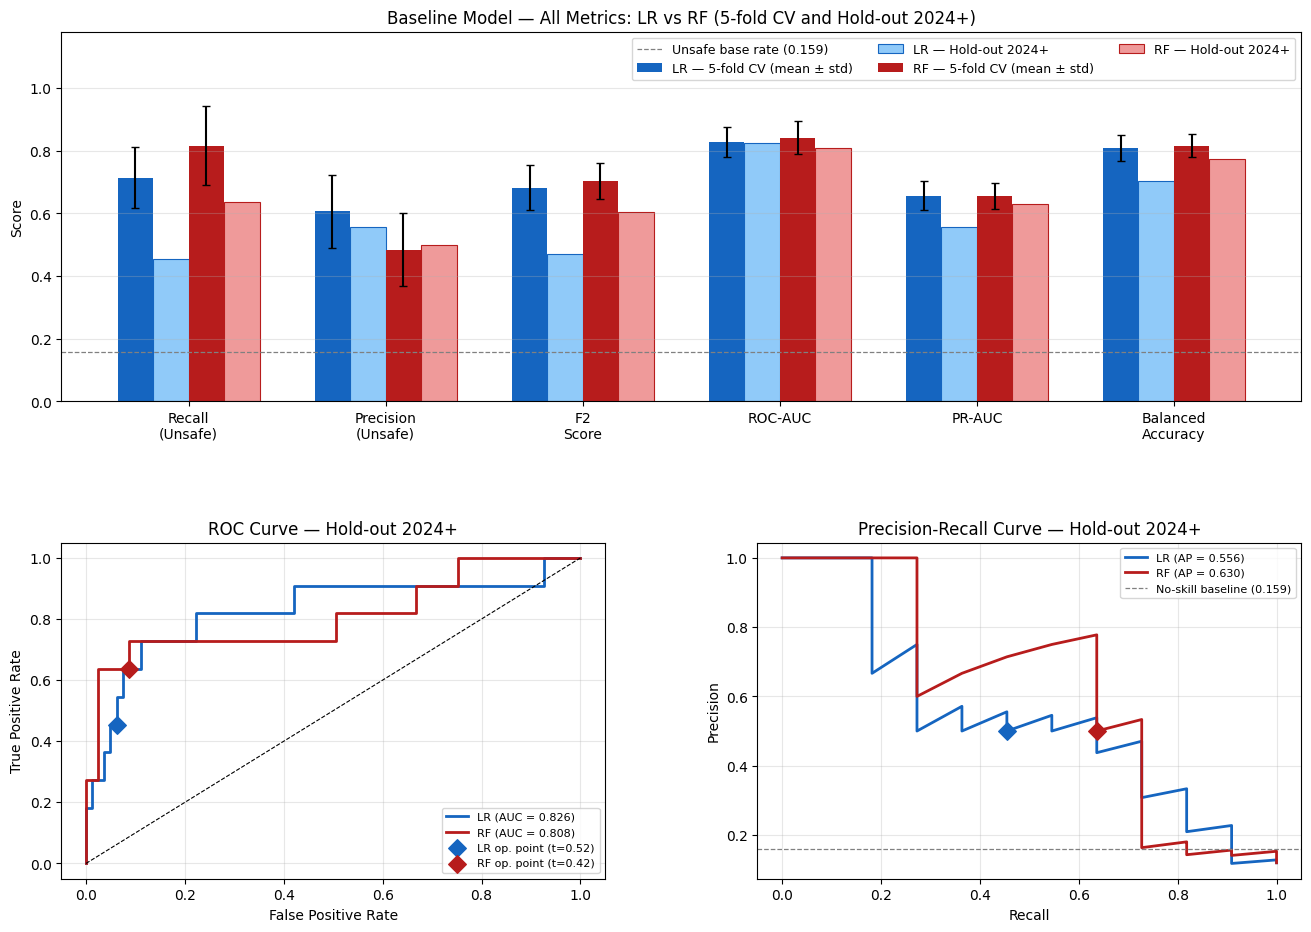

Saved: EDA/baseline_metrics_overview.png


In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve

METRIC_LABELS = {
    'unsafe_recall':    'Recall\n(Unsafe)',
    'unsafe_precision': 'Precision\n(Unsafe)',
    'f2':               'F2\nScore',
    'roc_auc':          'ROC-AUC',
    'pr_auc':           'PR-AUC',
    'balanced_accuracy':'Balanced\nAccuracy',
}
metrics       = list(METRIC_LABELS.keys())
metric_labels = list(METRIC_LABELS.values())

# Pull scalar values
lr_cv_mean = cv_df[cv_df['model'] == 'LR'][metrics].mean().values
lr_cv_std  = cv_df[cv_df['model'] == 'LR'][metrics].std().values
rf_cv_mean = cv_df[cv_df['model'] == 'RF'][metrics].mean().values
rf_cv_std  = cv_df[cv_df['model'] == 'RF'][metrics].std().values
lr_ho_vals = holdout_df[holdout_df['model'] == 'LR'][metrics].values[0]
rf_ho_vals = holdout_df[holdout_df['model'] == 'RF'][metrics].values[0]

# Probability scores for curves
lr_ho_proba_plot = gs_ho.predict_proba(X_ho_test)[:, 1]
rf_ho_proba_plot = rf_ho.predict_proba(X_ho_test)[:, 1]

UNSAFE_BASE_RATE = y.mean()
C_LR, C_LR_LIGHT = '#1565C0', '#90CAF9'
C_RF, C_RF_LIGHT = '#B71C1C', '#EF9A9A'

fig = plt.figure(figsize=(16, 11))
gs_layout = fig.add_gridspec(2, 2, height_ratios=[1.1, 1], hspace=0.40, wspace=0.28)

# ── Panel 1 (top, full width): grouped bar chart ──────────────────────────────
ax_bar = fig.add_subplot(gs_layout[0, :])
x     = np.arange(len(metrics))
width = 0.18

ax_bar.bar(x - 1.5*width, lr_cv_mean, width, yerr=lr_cv_std, capsize=3,
           color=C_LR,       label='LR — 5-fold CV (mean ± std)')
ax_bar.bar(x - 0.5*width, lr_ho_vals, width,
           color=C_LR_LIGHT, label='LR — Hold-out 2024+',  edgecolor=C_LR, linewidth=0.8)
ax_bar.bar(x + 0.5*width, rf_cv_mean, width, yerr=rf_cv_std, capsize=3,
           color=C_RF,       label='RF — 5-fold CV (mean ± std)')
ax_bar.bar(x + 1.5*width, rf_ho_vals, width,
           color=C_RF_LIGHT, label='RF — Hold-out 2024+',  edgecolor=C_RF, linewidth=0.8)

ax_bar.axhline(UNSAFE_BASE_RATE, color='grey', linestyle='--', linewidth=0.9,
               label=f'Unsafe base rate ({UNSAFE_BASE_RATE:.3f})')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_labels, fontsize=10)
ax_bar.set_ylim(0, 1.18)
ax_bar.set_ylabel('Score')
ax_bar.set_title('Baseline Model — All Metrics: LR vs RF (5-fold CV and Hold-out 2024+)', fontsize=12)
ax_bar.legend(ncol=3, fontsize=9, loc='upper right')
ax_bar.grid(axis='y', alpha=0.3)

# ── Panel 2 (bottom-left): ROC curves ─────────────────────────────────────────
ax_roc = fig.add_subplot(gs_layout[1, 0])

fpr_lr, tpr_lr, thr_lr = roc_curve(y_ho_test, lr_ho_proba_plot)
fpr_rf, tpr_rf, thr_rf = roc_curve(y_ho_test, rf_ho_proba_plot)

# Mark operating point at mean CV threshold
lr_op_idx = np.argmin(np.abs(thr_lr - mean_threshold_lr))
rf_op_idx = np.argmin(np.abs(thr_rf - mean_threshold_rf))

ax_roc.plot(fpr_lr, tpr_lr, color=C_LR, lw=2,
            label=f'LR (AUC = {roc_auc_score(y_ho_test, lr_ho_proba_plot):.3f})')
ax_roc.plot(fpr_rf, tpr_rf, color=C_RF, lw=2,
            label=f'RF (AUC = {roc_auc_score(y_ho_test, rf_ho_proba_plot):.3f})')
ax_roc.scatter(fpr_lr[lr_op_idx], tpr_lr[lr_op_idx], color=C_LR, s=80, zorder=5,
               marker='D', label=f'LR op. point (t={mean_threshold_lr:.2f})')
ax_roc.scatter(fpr_rf[rf_op_idx], tpr_rf[rf_op_idx], color=C_RF, s=80, zorder=5,
               marker='D', label=f'RF op. point (t={mean_threshold_rf:.2f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve — Hold-out 2024+')
ax_roc.legend(fontsize=8)
ax_roc.grid(alpha=0.3)

# ── Panel 3 (bottom-right): PR curves ─────────────────────────────────────────
ax_pr = fig.add_subplot(gs_layout[1, 1])

prec_lr, rec_lr, thr_pr_lr = precision_recall_curve(y_ho_test, lr_ho_proba_plot, pos_label=1)
prec_rf, rec_rf, thr_pr_rf = precision_recall_curve(y_ho_test, rf_ho_proba_plot, pos_label=1)

# Mark operating point on PR curve
lr_pr_op = np.argmin(np.abs(thr_pr_lr - mean_threshold_lr))
rf_pr_op = np.argmin(np.abs(thr_pr_rf - mean_threshold_rf))

ax_pr.plot(rec_lr, prec_lr, color=C_LR, lw=2,
           label=f'LR (AP = {average_precision_score(y_ho_test, lr_ho_proba_plot):.3f})')
ax_pr.plot(rec_rf, prec_rf, color=C_RF, lw=2,
           label=f'RF (AP = {average_precision_score(y_ho_test, rf_ho_proba_plot):.3f})')
ax_pr.scatter(rec_lr[lr_pr_op], prec_lr[lr_pr_op], color=C_LR, s=80, zorder=5, marker='D')
ax_pr.scatter(rec_rf[rf_pr_op], prec_rf[rf_pr_op], color=C_RF, s=80, zorder=5, marker='D')
ax_pr.axhline(UNSAFE_BASE_RATE, color='grey', linestyle='--', lw=0.9,
              label=f'No-skill baseline ({UNSAFE_BASE_RATE:.3f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve — Hold-out 2024+')
ax_pr.legend(fontsize=8)
ax_pr.grid(alpha=0.3)

plt.savefig('EDA/baseline_metrics_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: EDA/baseline_metrics_overview.png")

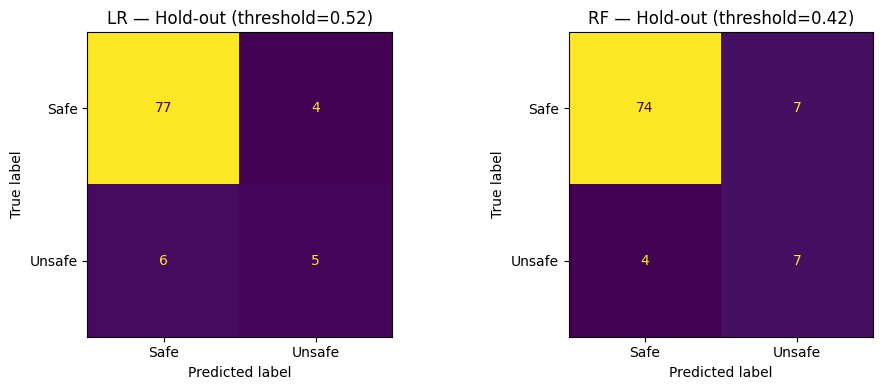

Saved: EDA/baseline_confusion_matrix.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, row in zip(axes, holdout_df.itertuples()):
    model_obj = gs_ho if row.model == 'LR' else rf_ho
    ho_proba = model_obj.predict_proba(X_ho_test)[:, 1]
    y_pred = (ho_proba >= row.threshold).astype(int)
    cm = confusion_matrix(y_ho_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Unsafe']).plot(ax=ax, colorbar=False)
    ax.set_title(f"{row.model} — Hold-out (threshold={row.threshold:.2f})")

plt.tight_layout()
plt.savefig('EDA/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: EDA/baseline_confusion_matrix.png")

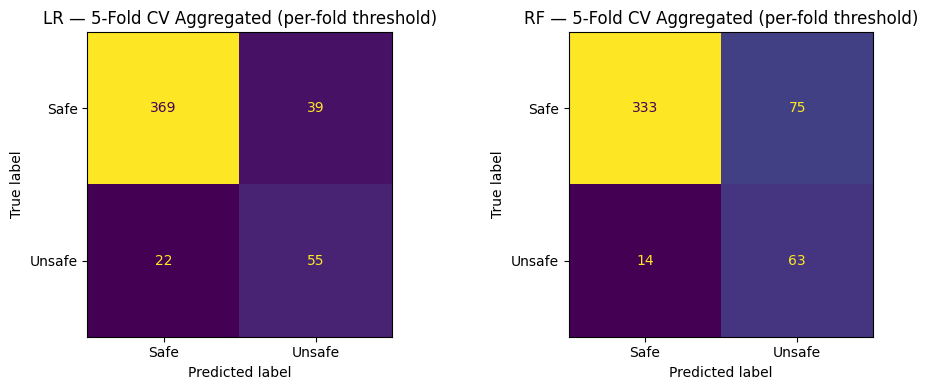

Saved: EDA/baseline_cv_confusion_matrix.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (model_name, y_pred) in zip(axes, [('LR', cv_y_pred_lr), ('RF', cv_y_pred_rf)]):
    cm = confusion_matrix(cv_y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Safe', 'Unsafe']).plot(ax=ax, colorbar=False)
    ax.set_title(f"{model_name} — 5-Fold CV Aggregated (per-fold threshold)")

plt.tight_layout()
plt.savefig('EDA/baseline_cv_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: EDA/baseline_cv_confusion_matrix.png")

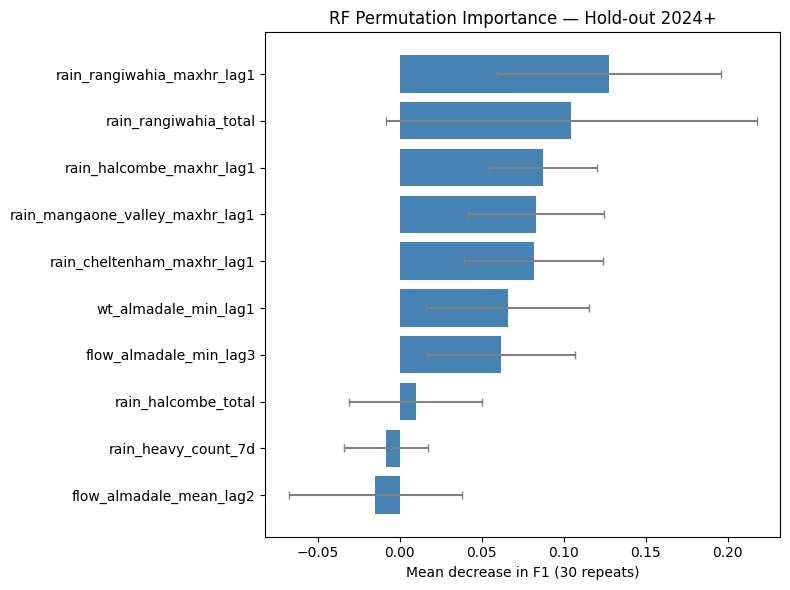

Saved: EDA/baseline_permutation_importance.png
                        feature  importance_mean  importance_std
     rain_rangiwahia_maxhr_lag1         0.127436        0.068264
          rain_rangiwahia_total         0.104556        0.112997
       rain_halcombe_maxhr_lag1         0.087391        0.032990
rain_mangaone_valley_maxhr_lag1         0.083170        0.041641
     rain_cheltenham_maxhr_lag1         0.081645        0.042378
           wt_almadale_min_lag1         0.065889        0.049792
         flow_almadale_min_lag3         0.061846        0.045212
            rain_halcombe_total         0.009767        0.040365
            rain_heavy_count_7d        -0.008497        0.025490
        flow_almadale_mean_lag2        -0.014919        0.052713


In [13]:
perm = permutation_importance(
    rf_ho,
    X_ho_test,
    y_ho_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring='f1',
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame({
        'feature': FINAL_FEATURES,
        'importance_mean': perm.importances_mean,
        'importance_std':  perm.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)
perm_df.to_csv('EDA/baseline_permutation_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    perm_df['feature'][::-1],
    perm_df['importance_mean'][::-1],
    xerr=perm_df['importance_std'][::-1],
    color='steelblue',
    ecolor='grey',
    capsize=3,
)
ax.set_xlabel('Mean decrease in F1 (30 repeats)')
ax.set_title('RF Permutation Importance — Hold-out 2024+')
plt.tight_layout()
plt.savefig('EDA/baseline_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: EDA/baseline_permutation_importance.png")
print(perm_df.to_string(index=False))